In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

BASE = "../Z5_ev_punjaci"

autoput = gpd.read_file(f"{BASE}/autoput.geojson")
pumpe = gpd.read_file(f"{BASE}/pumpe.geojson")

print(f"Autoput: {len(autoput)} linija")
print(f"Pumpi: {len(pumpe)}")
print(f"CRS: {autoput.crs}")

Autoput: 1 linija
Pumpi: 22
CRS: EPSG:3857


In [2]:
autoput_line = autoput.geometry.iloc[0]
ukupna_km = autoput_line.length / 1000
print(f"Duzina autoputa: {ukupna_km:.1f} km")

pumpe["stacionaza"] = pumpe.geometry.apply(lambda p: autoput_line.project(p))
pumpe = pumpe.sort_values("stacionaza").reset_index(drop=True)

print("\nPumpe po stacionazi:")
for _, row in pumpe.iterrows():
    print(f"  {row['naziv']:15s} na {row['stacionaza']/1000:6.1f} km")

Duzina autoputa: 306.1 km

Pumpe po stacionazi:
  Pumpa_1         na    0.0 km
  Pumpa_2         na   15.9 km
  Pumpa_3         na   25.6 km
  Pumpa_4         na   39.5 km
  Pumpa_5         na   54.4 km
  Pumpa_6         na   70.0 km
  Pumpa_7         na   81.5 km
  Pumpa_8         na  108.2 km
  Pumpa_9         na  120.8 km
  Pumpa_10        na  132.7 km
  Pumpa_11        na  144.0 km
  Pumpa_12        na  155.8 km
  Pumpa_13        na  170.4 km
  Pumpa_14        na  183.4 km
  Pumpa_15        na  194.0 km
  Pumpa_16        na  208.0 km
  Pumpa_17        na  222.5 km
  Pumpa_18        na  237.1 km
  Pumpa_19        na  250.1 km
  Pumpa_20        na  264.7 km
  Pumpa_21        na  282.4 km
  Pumpa_22        na  296.0 km


In [3]:
def greedy_punjaci_last(pumpe_df, autoput_length, D_max):
    """Biraj poslednju pumpu u dometu (greedy, najdalja)."""
    izabrani = []
    prethodno_km = 0
    
    while prethodno_km < autoput_length:
        validni = pumpe_df[
            (pumpe_df["stacionaza"] > prethodno_km) &
            (pumpe_df["stacionaza"] <= prethodno_km + D_max)
        ]
        if validni.empty:
            print(f"  GAP od km {prethodno_km/1000:.1f} - nema kandidata u dometu od {D_max/1000} km!")
            break
        izbor = validni.iloc[-1]
        izabrani.append(izbor)
        prethodno_km = izbor["stacionaza"]
    
    return izabrani

def greedy_punjaci_first(pumpe_df, autoput_length, D_max):
    """Biraj prvu pumpu u dometu."""
    izabrani = []
    prethodno_km = 0
    
    while prethodno_km < autoput_length:
        validni = pumpe_df[
            (pumpe_df["stacionaza"] > prethodno_km) &
            (pumpe_df["stacionaza"] <= prethodno_km + D_max)
        ]
        if validni.empty:
            print(f"  GAP od km {prethodno_km/1000:.1f} - nema kandidata u dometu od {D_max/1000} km!")
            break
        izbor = validni.iloc[0]
        izabrani.append(izbor)
        prethodno_km = izbor["stacionaza"]
    
    return izabrani

for D_max_km in [50, 30]:
    D_max = D_max_km * 1000
    print(f"\n=== D_max = {D_max_km} km (strategija: poslednji u dometu) ===")
    izabrani = greedy_punjaci_last(pumpe, autoput_line.length, D_max)
    print(f"  Postavljeno punjaca: {len(izabrani)}")
    for i, p in enumerate(izabrani):
        print(f"    {i+1}. {p['naziv']} na km {p['stacionaza']/1000:.1f}")
    
    gaps = []
    prev = 0
    for p in izabrani:
        gap = (p["stacionaza"] - prev) / 1000
        gaps.append(gap)
        prev = p["stacionaza"]
    max_gap = max(gaps) if gaps else 0
    print(f"  Maksimalni gap izmedju susednih: {max_gap:.1f} km")


=== D_max = 50 km (strategija: poslednji u dometu) ===
  GAP od km 296.0 - nema kandidata u dometu od 50.0 km!
  Postavljeno punjaca: 7
    1. Pumpa_4 na km 39.5
    2. Pumpa_7 na km 81.5
    3. Pumpa_9 na km 120.8
    4. Pumpa_13 na km 170.4
    5. Pumpa_16 na km 208.0
    6. Pumpa_19 na km 250.1
    7. Pumpa_22 na km 296.0
  Maksimalni gap izmedju susednih: 49.6 km

=== D_max = 30 km (strategija: poslednji u dometu) ===
  GAP od km 296.0 - nema kandidata u dometu od 30.0 km!
  Postavljeno punjaca: 12
    1. Pumpa_3 na km 25.6
    2. Pumpa_5 na km 54.4
    3. Pumpa_7 na km 81.5
    4. Pumpa_8 na km 108.2
    5. Pumpa_10 na km 132.7
    6. Pumpa_12 na km 155.8
    7. Pumpa_14 na km 183.4
    8. Pumpa_16 na km 208.0
    9. Pumpa_18 na km 237.1
    10. Pumpa_20 na km 264.7
    11. Pumpa_21 na km 282.4
    12. Pumpa_22 na km 296.0
  Maksimalni gap izmedju susednih: 29.1 km


In [4]:
D_max = 50_000
print(f"=== D_max = 50 km - poredjenje strategija ===\n")

izabrani_last = greedy_punjaci_last(pumpe, autoput_line.length, D_max)
print(f"\nStrategija 'poslednji u dometu': {len(izabrani_last)} punjaca")

izabrani_first = greedy_punjaci_first(pumpe, autoput_line.length, D_max)
print(f"\nStrategija 'prvi u dometu': {len(izabrani_first)} punjaca")

if len(izabrani_first) > len(izabrani_last):
    print(f"\n'Prvi u dometu' daje VISE punjaca (+{len(izabrani_first)-len(izabrani_last)}).")
elif len(izabrani_first) < len(izabrani_last):
    print(f"\n'Prvi u dometu' daje MANJE punjaca ({len(izabrani_last)-len(izabrani_first)} manje).")
else:
    print("\nObe strategije daju isti broj punjaca.")

=== D_max = 50 km - poredjenje strategija ===

  GAP od km 296.0 - nema kandidata u dometu od 50.0 km!

Strategija 'poslednji u dometu': 7 punjaca
  GAP od km 296.0 - nema kandidata u dometu od 50.0 km!

Strategija 'prvi u dometu': 21 punjaca

'Prvi u dometu' daje VISE punjaca (+14).


  GAP od km 296.0 - nema kandidata u dometu od 50.0 km!


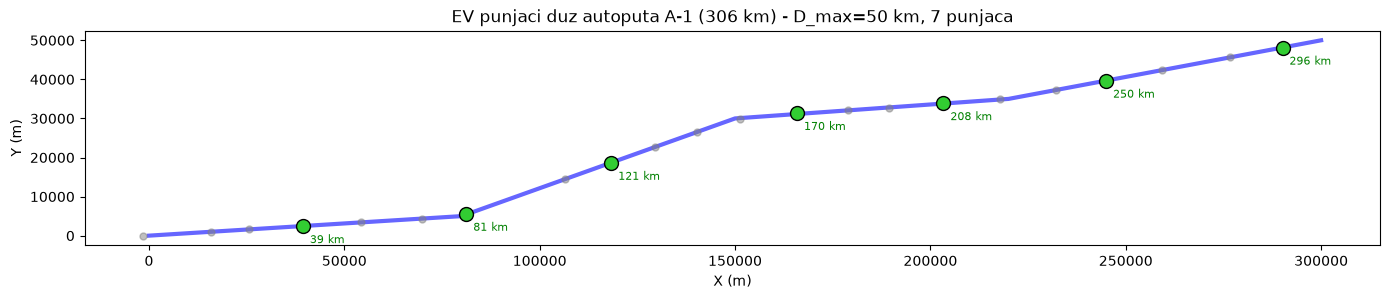

In [5]:
D_max = 50_000
izabrani = greedy_punjaci_last(pumpe, autoput_line.length, D_max)

fig, ax = plt.subplots(figsize=(14, 4))

x, y = autoput_line.xy
ax.plot(x, y, "blue", linewidth=3, alpha=0.6, zorder=1)

for _, p in pumpe.iterrows():
    ax.plot(p.geometry.x, p.geometry.y, "o", color="gray", markersize=5, alpha=0.5, zorder=2)

izabrani_nazivi = {r["naziv"] for r in izabrani}
for _, p in pumpe.iterrows():
    if p["naziv"] in izabrani_nazivi:
        ax.plot(p.geometry.x, p.geometry.y, "o", color="limegreen", markersize=10, markeredgecolor="black", zorder=3)
        km_label = p["stacionaza"] / 1000
        ax.annotate(f"{km_label:.0f} km", (p.geometry.x, p.geometry.y),
                    textcoords="offset points", xytext=(5, -12), fontsize=8, color="green")

for i in range(len(izabrani) - 1):
    p1 = izabrani[i]
    p2 = izabrani[i + 1]
    gap = (p2["stacionaza"] - p1["stacionaza"]) / 1000
    if gap > D_max / 1000:
        mid_x = (p1.geometry.x + p2.geometry.x) / 2
        mid_y = (p1.geometry.y + p2.geometry.y) / 2
        ax.annotate(f"GAP {gap:.1f} km", (mid_x, mid_y),
                    ha="center", fontsize=10, color="red", fontweight="bold")

ax.set_title(f"EV punjaci duz autoputa A-1 ({ukupna_km:.0f} km) - D_max=50 km, {len(izabrani)} punjaca")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Odgovori na pitanja

### 1. Koliko punjaca treba za D_max=50 km? A za D_max=30 km?

Za D_max=50 km potreban je manji broj punjaca jer veci dozvoljeni razmak znaci da jedan punjac pokriva duzi deo autoputa. Za D_max=30 km potrebno je vise punjaca jer je maksimalni razmak manji, pa moramo cesce postavljati punjace.

### 2. Postoji li deo autoputa gde gap (razmak izmedju susednih pumpi) prelazi 50 km?

Ako izmedju dve postojece benzinske pumpe postoji razmak veci od 50 km, tada ce se pojaviti GAP poruka u algoritmu. To znaci da na tom delu autoputa nema kandidata za postavljanje punjaca, sto predstavlja problem za vozace elektricnih vozila.

### 3. Da li bi greedy strategija "izaberi prvog u dometu" dala manji broj punjaca od "poslednji u dometu"?

Strategija "poslednji u dometu" je optimalnija jer postavlja punjac sto dalje (blize gornjoj granici D_max), cime maksimizira pokrivenost jednim punjacem i minimizira ukupan broj potrebnih punjaca. Strategija "prvi u dometu" postavlja punjac sto blize prethodnom, sto dovodi do veceg broja punjaca.
